# 02. 선형변환 시각화

**목표:** 행렬이 공간을 어떻게 변형시키는지 격자 애니메이션으로 이해한다.

**로보틱스 연결:**
- 회전행렬 $R$ = 로봇 관절 좌표계 회전
- 변환행렬 $T$ = 링크 간 좌표 변환 (순기구학의 핵심)
- 행렬식(det) = 변환 후 부피 변화율 → 0이면 특이 자세(Singularity)

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}, \quad \det(R) = 1$$

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import os
os.makedirs('assets', exist_ok=True)

plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 격자 변환 시각화 — 4가지 변환 비교

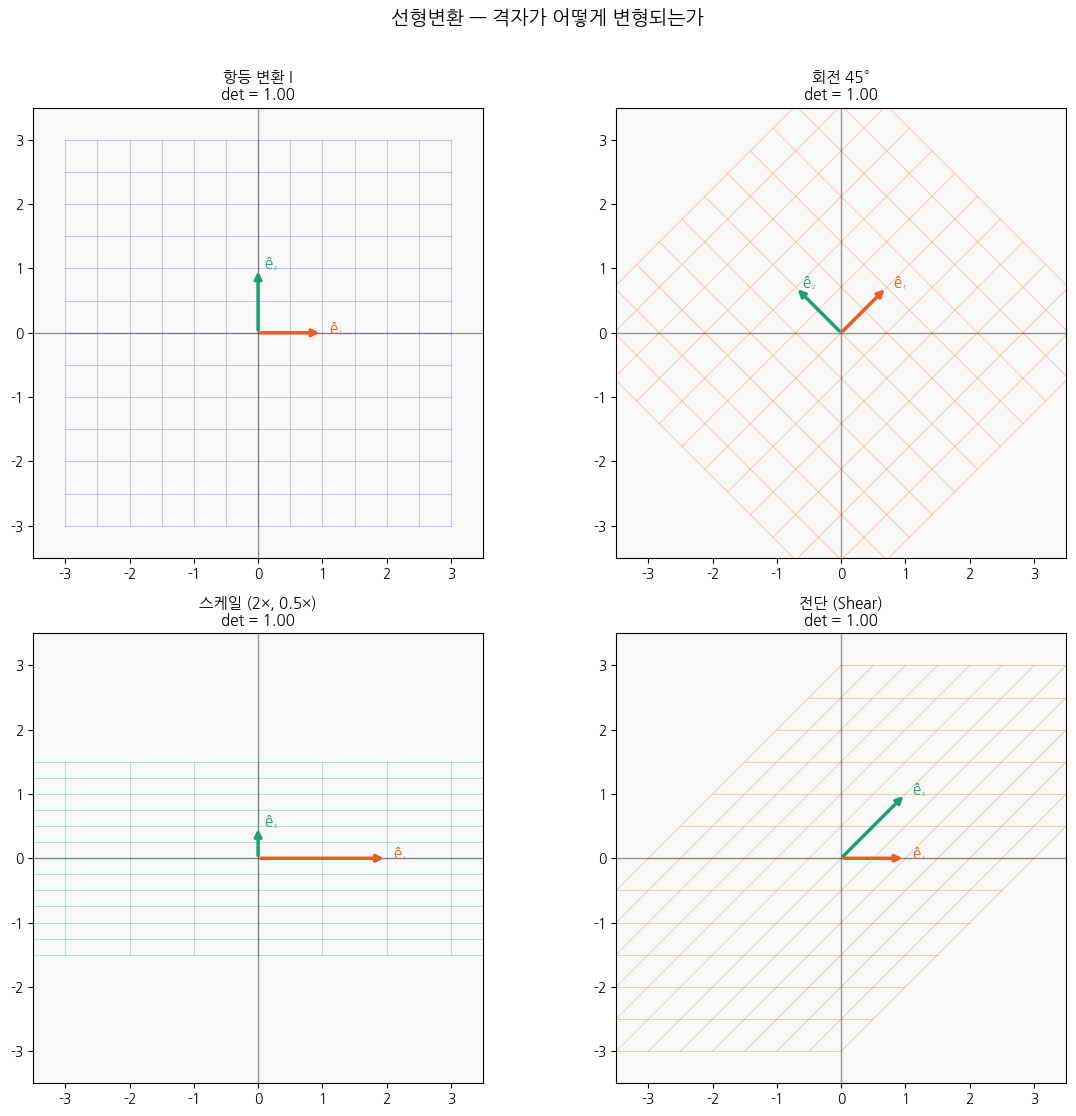

In [22]:
def draw_grid(ax, M, title, color='#534AB7', n=6):
    """격자선을 행렬 M으로 변환해서 그린다."""
    lim = 3
    lines = np.linspace(-lim, lim, n*2+1)

    # 수평·수직 격자선 변환
    for v in lines:
        # 수평선: y=v 에서 x 범위
        pts_h = np.array([[x, v] for x in np.linspace(-lim, lim, 50)]).T
        t_h = M @ pts_h
        ax.plot(t_h[0], t_h[1], color=color, lw=0.6, alpha=0.35)
        # 수직선: x=v
        pts_v = np.array([[v, y] for y in np.linspace(-lim, lim, 50)]).T
        t_v = M @ pts_v
        ax.plot(t_v[0], t_v[1], color=color, lw=0.6, alpha=0.35)

    # 기저 벡터
    e1 = M @ np.array([1, 0])
    e2 = M @ np.array([0, 1])
    ax.annotate('', xy=e1, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color='#E85D24', lw=2.5))
    ax.annotate('', xy=e2, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2.5))
    ax.text(e1[0]+0.1, e1[1], 'ê₁', color='#E85D24', fontsize=11, fontweight='bold')
    ax.text(e2[0]+0.1, e2[1], 'ê₂', color='#1D9E75', fontsize=11, fontweight='bold')

    det = np.linalg.det(M)
    ax.set_title(f'{title}\ndet = {det:.2f}', fontsize=11, pad=6)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal'); ax.grid(False)
    ax.axhline(0, color='k', lw=1, alpha=0.4)
    ax.axvline(0, color='k', lw=1, alpha=0.4)

transforms = [
    (np.eye(2),                          '항등 변환 I'),
    (np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
               [np.sin(np.pi/4),  np.cos(np.pi/4)]]), '회전 45°'),
    (np.array([[2, 0], [0, 0.5]]),       '스케일 (2×, 0.5×)'),
    (np.array([[1, 1], [0, 1]]),         '전단 (Shear)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
colors = ['#534AB7', '#E85D24', '#1D9E75', '#BA7517']

for ax, (M, title), color in zip(axes.flat, transforms, colors):
    draw_grid(ax, M, title, color)

plt.suptitle('선형변환 — 격자가 어떻게 변형되는가', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/02_linear_transforms.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 변환 보간 애니메이션 — 항등 → 회전

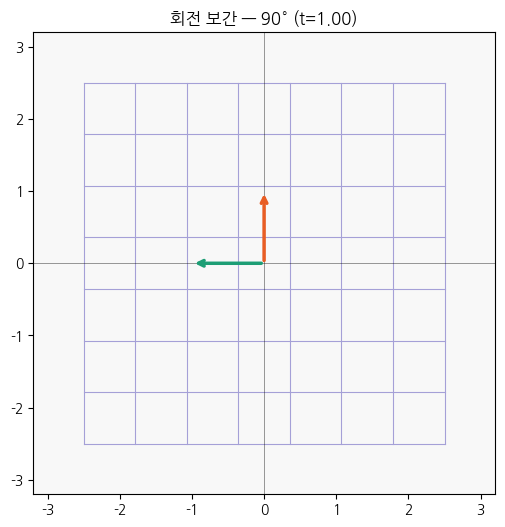

GIF 저장 완료: assets/02_transform_animation.gif


In [23]:
def make_grid_points(n=8, lim=2.5):
    lines = np.linspace(-lim, lim, n)
    pts = []
    for v in lines:
        for t in np.linspace(-lim, lim, 60):
            pts.append([t, v])   # 수평선
        pts.append([np.nan, np.nan])
        for t in np.linspace(-lim, lim, 60):
            pts.append([v, t])   # 수직선
        pts.append([np.nan, np.nan])
    return np.array(pts).T

grid = make_grid_points()
M_target = np.array([[0, -1], [1, 0]])  # 90도 회전

fig, ax = plt.subplots(figsize=(6, 6))
line, = ax.plot([], [], lw=0.8, color='#534AB7', alpha=0.5)
e1_arr = ax.annotate('', xy=[1,0], xytext=[0,0],
                     arrowprops=dict(arrowstyle='->', color='#E85D24', lw=2.5))
e2_arr = ax.annotate('', xy=[0,1], xytext=[0,0],
                     arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2.5))
title = ax.set_title('', fontsize=12)

ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.7, alpha=0.4)
ax.axvline(0, color='k', lw=0.7, alpha=0.4)

def animate(frame):
    t = frame / 60
    # 선형 보간
    M = (1 - t) * np.eye(2) + t * M_target
    tgrid = M @ grid
    line.set_data(tgrid[0], tgrid[1])
    e1 = M @ np.array([1, 0])
    e2 = M @ np.array([0, 1])
    e1_arr.xy = e1; e2_arr.xy = e2
    title.set_text(f'회전 보간 — {t*90:.0f}° (t={t:.2f})')
    return line, e1_arr, e2_arr, title

ani = animation.FuncAnimation(fig, animate, frames=61, interval=40, blit=True)
ani.save('assets/02_transform_animation.gif', writer='pillow', fps=25, dpi=100)
plt.show()
print('GIF 저장 완료: assets/02_transform_animation.gif')

## 3. 행렬식 (Determinant) — 넓이 변화율

$$\det(A) = \text{변환 후 넓이} / \text{원래 넓이}$$

로보틱스에서 $\det(J) = 0$ 이면 **특이 자세(Singularity)** — 로봇이 특정 방향으로 움직일 수 없게 된다.

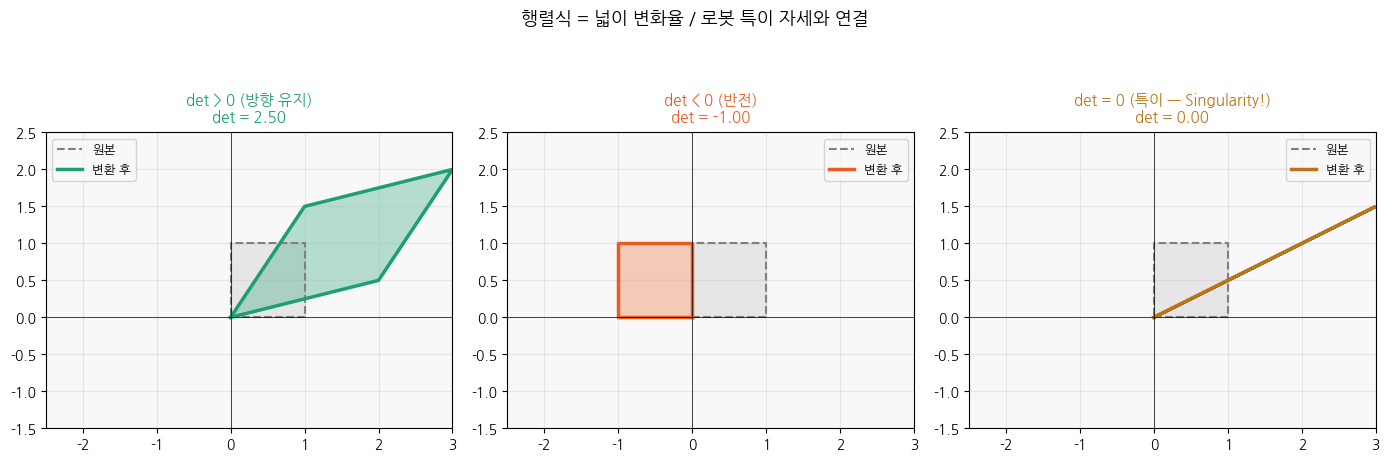

det > 0 (방향 유지): det = 2.5000
det < 0 (반전): det = -1.0000
det = 0 (특이 — Singularity!): det = 0.0000


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cases = [
    (np.array([[2., 1.], [0.5, 1.5]]), 'det > 0 (방향 유지)', '#1D9E75'),
    (np.array([[-1., 0.], [0., 1.]]),  'det < 0 (반전)', '#E85D24'),
    (np.array([[1., 2.], [0.5, 1.]]),  'det = 0 (특이 — Singularity!)', '#BA7517'),
]

square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T

for ax, (M, title, color) in zip(axes, cases):
    # 원본
    ax.fill(square[0], square[1], alpha=0.15, color='gray')
    ax.plot(square[0], square[1], 'gray', lw=1.5, linestyle='--', label='원본')
    # 변환
    t_sq = M @ square
    ax.fill(t_sq[0], t_sq[1], alpha=0.3, color=color)
    ax.plot(t_sq[0], t_sq[1], color=color, lw=2.5, label='변환 후')

    det = np.linalg.det(M)
    ax.set_title(f'{title}\ndet = {det:.2f}', fontsize=11, color=color, pad=8)
    ax.set_xlim(-2.5, 3); ax.set_ylim(-1.5, 2.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.legend(fontsize=9)

plt.suptitle('행렬식 = 넓이 변화율 / 로봇 특이 자세와 연결', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('assets/02_determinant.png', dpi=150, bbox_inches='tight')
plt.show()

for M, title, _ in cases:
    print(f'{title}: det = {np.linalg.det(M):.4f}')

## 요약

| 변환 | 행렬 | det | 로보틱스 의미 |
|------|------|-----|---------------|
| 회전 | $R(\theta)$ | 1 | 관절 회전 |
| 스케일 | $S$ | $s_x s_y$ | 길이 단위 변환 |
| 전단 | Shear | 1 | 변형 (드문 경우) |
| 특이 | $\det=0$ | 0 | 로봇 특이 자세 |

**다음 노트북:** `03_eigenvalues_eigenvectors.ipynb` — 고유값 분해